### Imports + load data


`sessions`  
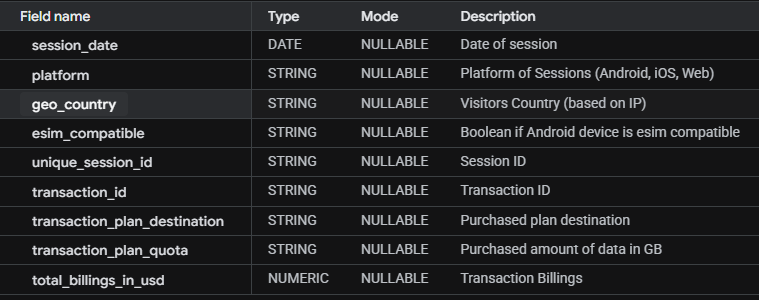

`events`  
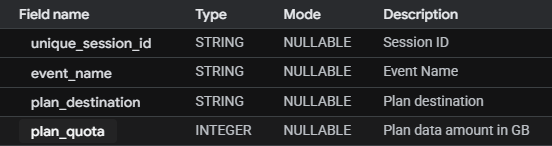


In [78]:
import pandas as pd
import duckdb

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

sessions = pd.read_csv("./data/sessions.csv", parse_dates=["session_date"])
events = pd.read_csv("./data/events.csv")

display(sessions.head(1)), display(events.head(1))

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
0,2024-08-01,ANDROID,Tunisia,true,1722530830-9c47c790289045bf156fe4e25a60e3a7,NaN,NaN,NaN,0.0000


,unique_session_id,event_name,plan_destination,plan_quota
0,1724145563-26F74962FC3C4ABA829693247D77E175,click_to_order_1,AD,NaN


(None, None)

Register tables in DuckDB


In [79]:
con = duckdb.connect()

con.register("sessions", sessions)
con.register("events", events)

### Basic data scan


In [80]:
print("sessions:", sessions.shape)
print("events:", events.shape)

display(sessions.info())
display(events.info())

# display(sessions.head())
# display(events.head())

sessions: (274695, 9)
events: (252450, 4)
<class 'pandas.DataFrame'>
RangeIndex: 274695 entries, 0 to 274694
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   session_date                  274695 non-null  datetime64[us]
 1   platform                      274695 non-null  str           
 2   geo_country                   274695 non-null  str           
 3   esim_compatible               274695 non-null  str           
 4   unique_session_id             274695 non-null  str           
 5   transaction_id                25133 non-null   str           
 6   transaction_plan_destination  25133 non-null   str           
 7   transaction_plan_quota        25133 non-null   float64       
 8   total_billings_in_usd         274695 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 18.9 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 252450 entries, 0 to 252449
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   unique_session_id  252450 non-null  str    
 1   event_name         252450 non-null  str    
 2   plan_destination   252449 non-null  str    
 3   plan_quota         82013 non-null   float64
dtypes: float64(1), str(3)
memory usage: 7.7 MB


None

In [81]:
display(sessions.describe(include="all"))
display(events.describe(include="all"))

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
count,274695,274695,274695,274695,274695,25133,25133,"25,133.0000","274,695.0000"
unique,NaN,2,42,3,241548,25133,155,NaN,NaN
top,NaN,IOS,United States,not_applicable,1720967885-721d01f8cfec84a9b964c66287048e91,582be001-336a-4d32-bb88-90a828120b71,US,NaN,NaN
freq,NaN,147224,81278,147224,22,1,6875,NaN,NaN
mean,2024-08-14 17:42:34.421449,NaN,NaN,NaN,NaN,NaN,NaN,6.7398,1.3055
min,2024-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.0000
25%,2024-08-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,3.0000,0.0000
50%,2024-08-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,5.0000,0.0000
75%,2024-08-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,10.0000,0.0000
max,2024-08-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,179.9900


,unique_session_id,event_name,plan_destination,plan_quota
count,252450,252450,252449,"82,013.0000"
unique,115996,2,178,NaN
top,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,US,NaN
freq,172,170437,47520,NaN
mean,NaN,NaN,NaN,5.6285
std,NaN,NaN,NaN,6.8161
min,NaN,NaN,NaN,1.0000
25%,NaN,NaN,NaN,1.0000
50%,NaN,NaN,NaN,3.0000
75%,NaN,NaN,NaN,10.0000


### Check table grain

- sessions
- events

`sessions` - is not perfectly one row per session.  
`events` - is event-level and has many rows per session.

Session with highest freequency in events table:

- 1724723941-85d9250152d7174971df6119269db913


In [82]:
query = """
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids,
    COUNT(*) - COUNT(DISTINCT unique_session_id) AS duplicated_session_rows
FROM sessions
"""

con.execute(query).df()

,rows,unique_session_ids,duplicated_session_rows
0,274695,241548,33147


In [83]:
query = """
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids,
    COUNT(*) - COUNT(DISTINCT unique_session_id) AS extra_event_rows
FROM events
"""

con.execute(query).df()

,rows,unique_session_ids,extra_event_rows
0,252450,115996,136454


Checking the most frequent session


In [84]:
query = """
SELECT
    *
FROM sessions
where unique_session_id in ('1724723941-85d9250152d7174971df6119269db913')
order by unique_session_id, session_date
"""
display(con.execute(query).df())

query = """
SELECT
    *
FROM events
where unique_session_id in ('1724723941-85d9250152d7174971df6119269db913')
order by unique_session_id, event_name
"""
display(con.execute(query).df())

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
0,2024-08-27,ANDROID,Morocco,true,1724723941-85d9250152d7174971df6119269db913,None,None,NaN,0.0000


,unique_session_id,event_name,plan_destination,plan_quota
0,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AE,NaN
1,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,ME,NaN
2,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AI,NaN
3,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AL,NaN
4,1724723941-85d9250152d7174971df6119269db913,click_to_order_1,AM,NaN
...,...,...,...,...
167,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,CZ,1.0000
168,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,MA,1.0000
169,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,TH,1.0000
170,1724723941-85d9250152d7174971df6119269db913,click_to_order_2,TR,1.0000


If this query returns 0 rows, then those fields are stable at that grain.


In [85]:
query = """
SELECT
    session_date,
    unique_session_id,
    COUNT(*) AS rows_in_group,
    COUNT(DISTINCT COALESCE(platform, '__NULL__')) AS platform_values,
    COUNT(DISTINCT COALESCE(geo_country, '__NULL__')) AS geo_country_values,
    COUNT(DISTINCT COALESCE(esim_compatible, '__NULL__')) AS esim_compatible_values
FROM sessions
GROUP BY
    session_date,
    unique_session_id
HAVING
    platform_values > 1
    OR geo_country_values > 1
    OR esim_compatible_values > 1
ORDER BY rows_in_group DESC
"""
grain_check = con.execute(query).df()
display(grain_check)

assert (
    grain_check.shape[0] == 0
), "Conflict found: session attributes are not stable within session_date + unique_session_id"

,session_date,unique_session_id,rows_in_group,platform_values,geo_country_values,esim_compatible_values


### Check dates and platforms


In [86]:
query = """
SELECT
    MIN(session_date) AS min_date,
    MAX(session_date) AS max_date,
    COUNT(DISTINCT session_date) AS days
FROM sessions
"""

con.execute(query).df()

,min_date,max_date,days
0,2024-08-01,2024-08-27,27


In [87]:
query = """
SELECT
    platform,
    esim_compatible,
    COUNT(*) AS rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids
FROM sessions
GROUP BY platform, esim_compatible
ORDER BY rows DESC
"""

con.execute(query).df()

,platform,esim_compatible,rows,unique_session_ids
0,IOS,not_applicable,147224,128872
1,ANDROID,true,98510,85603
2,ANDROID,false,28961,27073


### Check transaction logic


sessions table has unique_transactions records that are not duplicated.  
It means that each row is actually unique but can belong to the same unique_session_id.


In [88]:
query = """
SELECT
    COUNT(*) AS rows,
    COUNT(transaction_id) AS transaction_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions,
    SUM(total_billings_in_usd) AS total_revenue
FROM sessions
"""

con.execute(query).df()

,rows,transaction_rows,unique_transactions,total_revenue
0,274695,25133,25133,"358,625.8500"


In [89]:
query = """
SELECT
    COUNT(DISTINCT transaction_id) AS unique_transactions
FROM sessions
"""

con.execute(query).df()

,unique_transactions
0,25133


In [90]:
query = """
SELECT
    COUNT( transaction_id) AS transactions
FROM sessions
where transaction_id IS NOT NULL
"""

con.execute(query).df()

,transactions
0,25133


### Clean session-level table

We will use session date + unique session ID as safer grain, not only unique_session_id.


In [91]:
query = """
SELECT
    session_date,
    unique_session_id,

    platform AS platform,
    geo_country AS geo_country,
    esim_compatible AS esim_compatible,

    COUNT(*) AS rows_in_session,
    COUNT(transaction_id) AS transaction_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions,

    SUM(COALESCE(total_billings_in_usd, 0)) AS revenue
FROM sessions
GROUP BY
    session_date,
    unique_session_id, 
    platform, 
    geo_country, 
    esim_compatible
"""

session_clean = con.execute(query).df()
session_clean

,session_date,unique_session_id,platform,geo_country,esim_compatible,rows_in_session,transaction_rows,unique_transactions,revenue
0,2024-08-22,1724286259-71797b66e5fa3b1bb608ae884e7c8e5f,ANDROID,United States,true,1,0,0,0.0000
1,2024-08-22,1724294454-2726c4c37bc43aaf453a6a0a2d86118f,ANDROID,Canada,true,1,0,0,0.0000
2,2024-08-22,1724315182-8267259ffa8a6917458c4c531ce98141,ANDROID,United Kingdom,true,2,1,1,4.4900
3,2024-08-22,1724358640-c9b4143774a7bcd02f0567f570249c45,ANDROID,United States,true,1,0,0,0.0000
4,2024-08-22,1724336604-7fa06b7fc5a98bc64edb500724395e42,ANDROID,Latvia,true,1,0,0,0.0000
...,...,...,...,...,...,...,...,...,...
249673,2024-08-11,1723351334-B8690E756EB641339362ACBC77E7D5F2,IOS,Lithuania,not_applicable,1,0,0,0.0000
249674,2024-08-11,1723395995-AFEDBC21FC134B5C882146FC7CF52133,IOS,Canada,not_applicable,1,0,0,0.0000
249675,2024-08-11,1723406694-B606414EE80A49AC9E3020EEBA98EF14,IOS,United Kingdom,not_applicable,1,0,0,0.0000
249676,2024-08-11,1723361917-84486896B1AE4505A62149A0A7D07B66,IOS,United States,not_applicable,1,0,0,0.0000


In [92]:
session_id_date_check = con.execute("""
SELECT
    unique_session_id,
    COUNT(DISTINCT session_date) AS active_dates
FROM sessions
GROUP BY unique_session_id
HAVING active_dates > 1
ORDER BY active_dates DESC
""").df()

session_id_date_check.head()

,unique_session_id,active_dates
0,1720967885-721d01f8cfec84a9b964c66287048e91,22
1,1722804049-ffe27d1b30fc0f74fcfe1626b7eafa01,18
2,1722696892-48938d4ffb2725cc714c9d5ace87f6d7,14
3,1723650130-50765428ce5d603a677d19104b5db6d3,14
4,1723555581-a7b4d338bdb398cdbbc7218309323b78,14


In [93]:
query = """
SELECT
   *
FROM sessions
where unique_session_id = '1720967885-721d01f8cfec84a9b964c66287048e91'
"""

con.execute(query).df()

,session_date,platform,geo_country,esim_compatible,unique_session_id,transaction_id,transaction_plan_destination,transaction_plan_quota,total_billings_in_usd
0,2024-08-01,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
1,2024-08-03,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
2,2024-08-04,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
3,2024-08-05,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
4,2024-08-06,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
5,2024-08-08,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
6,2024-08-09,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
7,2024-08-10,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
8,2024-08-11,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000
9,2024-08-12,ANDROID,Canada,true,1720967885-721d01f8cfec84a9b964c66287048e91,None,None,NaN,0.0000


In [94]:
query = """
SELECT
   *
FROM events
where unique_session_id = '1720967885-721d01f8cfec84a9b964c66287048e91'
"""

con.execute(query).df()

,unique_session_id,event_name,plan_destination,plan_quota


The sessions table appears to represent daily visitor/session activity, not actual post-purchase eSIM usage. The `geo_country` field describes the visitor's country based on IP, while `transaction_plan_destination` describes the destination of the purchased eSIM plan.

Although the column is named `unique_session_id`, the same identifier can appear across multiple dates. Therefore, I treat `session_date + unique_session_id` as the main analysis grain for daily platform performance.

Purchases are identified using non-null `transaction_id` values in the sessions table. The events table is used to reconstruct funnel behavior before purchase, mainly through `click_to_order_1` and `click_to_order_2`.


Creaating a `session_day` table. It is a controlled metric table where one row means one visitor/session-day context.


In [95]:
query = """
SELECT
    session_date,
    unique_session_id,
    platform,
    geo_country,
    esim_compatible,
    COUNT(*) AS source_rows,
    COUNT(transaction_id) AS transaction_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions,
    CASE
        WHEN COUNT(transaction_id) > 0 THEN 1
        ELSE 0
    END AS has_purchase,
    SUM(COALESCE(total_billings_in_usd, 0)) AS revenue
FROM sessions
GROUP BY
    session_date,
    unique_session_id,
    platform,
    geo_country,
    esim_compatible
"""

session_day = con.execute(query).df()
con.register("session_day", session_day)
session_day

,session_date,unique_session_id,platform,geo_country,esim_compatible,source_rows,transaction_rows,unique_transactions,has_purchase,revenue
0,2024-08-22,1724350584-b78bfa1aad95100799da53605d186a73,ANDROID,United Kingdom,true,2,1,1,1,12.9900
1,2024-08-22,1724351504-2cf22e63d9f0b160412ad90a07a35b44,ANDROID,United States,true,1,0,0,0,0.0000
2,2024-08-22,1724327510-eb42e373133e2777a317abf3c7f79355,ANDROID,United Kingdom,true,1,0,0,0,0.0000
3,2024-08-22,1724338889-3e6aca3f11ad9cbfa4171ae8ef07e749,ANDROID,Norway,true,2,1,1,1,9.9900
4,2024-08-22,1724328990-2f898d660915361227b7cd107ab2dfd3,ANDROID,Canada,true,1,0,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...
249673,2024-08-11,1723344617-5BEC8E0D231346DD99D073F583669617,IOS,United States,not_applicable,1,0,0,0,0.0000
249674,2024-08-11,1723408081-C397307B57D04612B1E2D4834A4E7E88,IOS,Morocco,not_applicable,1,0,0,0,0.0000
249675,2024-08-11,1723384906-2EDC1C3D94994236B2F98765F63120A1,IOS,United States,not_applicable,1,0,0,0,0.0000
249676,2024-08-11,1723332293-27920E5AADC84FBEAF0E36C9EDA7AF9E,IOS,United States,not_applicable,1,0,0,0,0.0000


### 1. Platform performance and eSIM compatibility


In [96]:
query = """
SELECT
    platform,
    esim_compatible,
    COUNT(*) AS session_days,
    SUM(has_purchase) AS buyers,
    SUM(revenue) AS revenue,

    SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
    SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day,
    SUM(revenue) * 1.0 / NULLIF(SUM(has_purchase), 0) AS revenue_per_buyer
FROM session_day
GROUP BY platform, esim_compatible
ORDER BY platform
"""

platform_perf = con.execute(query).df()
platform_perf.head()

,platform,esim_compatible,session_days,buyers,revenue,conversion_rate,revenue_per_session_day,revenue_per_buyer
0,ANDROID,true,90051,"8,258.0000","116,945.4600",0.0917,1.2987,14.1615
1,ANDROID,false,28851,110.0000,"1,238.1900",0.0038,0.0429,11.2563
2,IOS,not_applicable,130776,"16,093.0000","240,442.2000",0.1231,1.8386,14.9408


### 2. Daily anomaly analysis


In [97]:
query = """
SELECT
    session_date,
    platform,
    COUNT(*) AS session_days,
    SUM(has_purchase) AS buyers,
    SUM(revenue) AS revenue,

    SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
    SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day
FROM session_day
GROUP BY session_date, platform
ORDER BY session_date, platform
"""

daily_platform = con.execute(query).df()
daily_platform.head(15)

,session_date,platform,session_days,buyers,revenue,conversion_rate,revenue_per_session_day
0,2024-08-01,ANDROID,3892,304.0000,"4,043.1300",0.0781,1.0388
1,2024-08-01,IOS,4063,558.0000,"8,093.5800",0.1373,1.9920
2,2024-08-02,ANDROID,3953,322.0000,"4,664.9400",0.0815,1.1801
3,2024-08-02,IOS,4122,591.0000,"8,287.0800",0.1434,2.0105
4,2024-08-03,ANDROID,4123,320.0000,"4,140.2300",0.0776,1.0042
5,2024-08-03,IOS,4225,637.0000,"9,247.8600",0.1508,2.1888
6,2024-08-04,ANDROID,4587,300.0000,"4,091.1800",0.0654,0.8919
7,2024-08-04,IOS,4638,633.0000,"9,175.5000",0.1365,1.9783
8,2024-08-05,ANDROID,4923,325.0000,"4,495.7100",0.0660,0.9132
9,2024-08-05,IOS,4583,542.0000,"7,687.9400",0.1183,1.6775


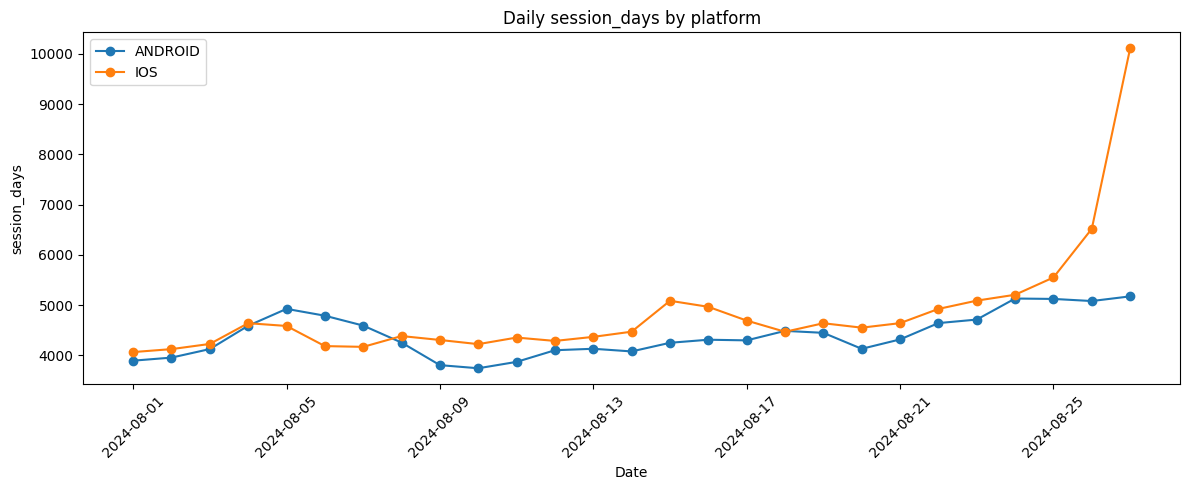

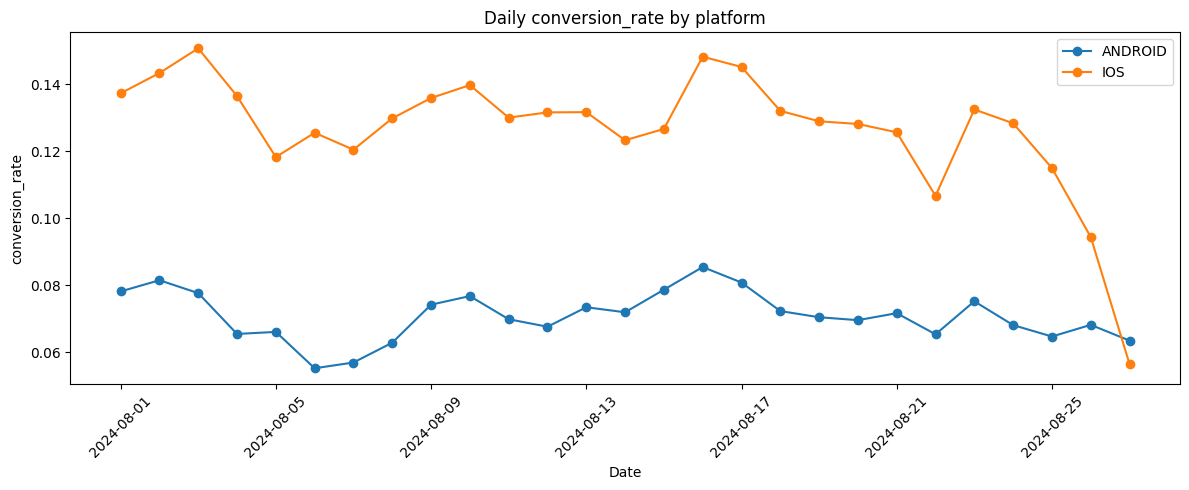

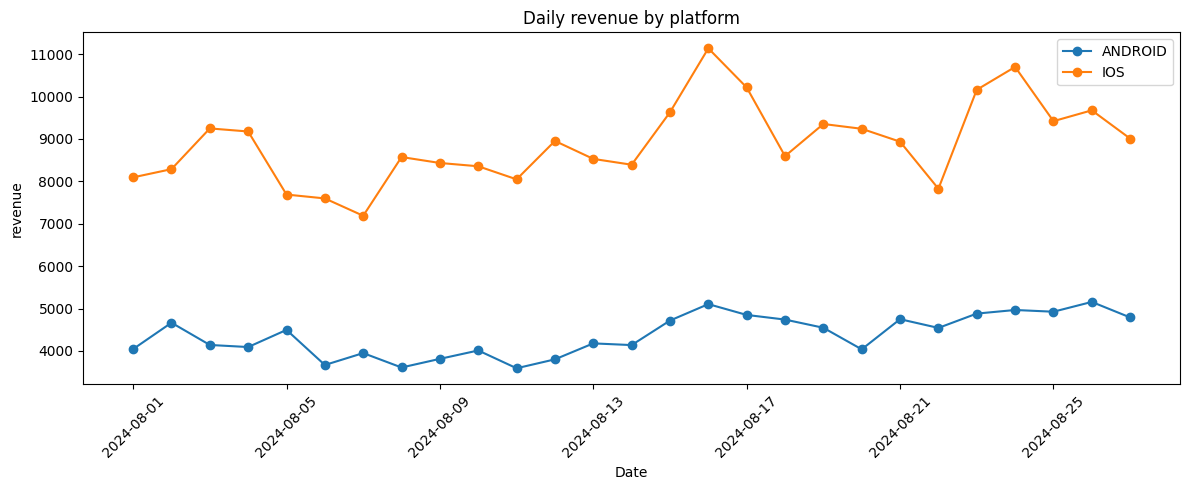

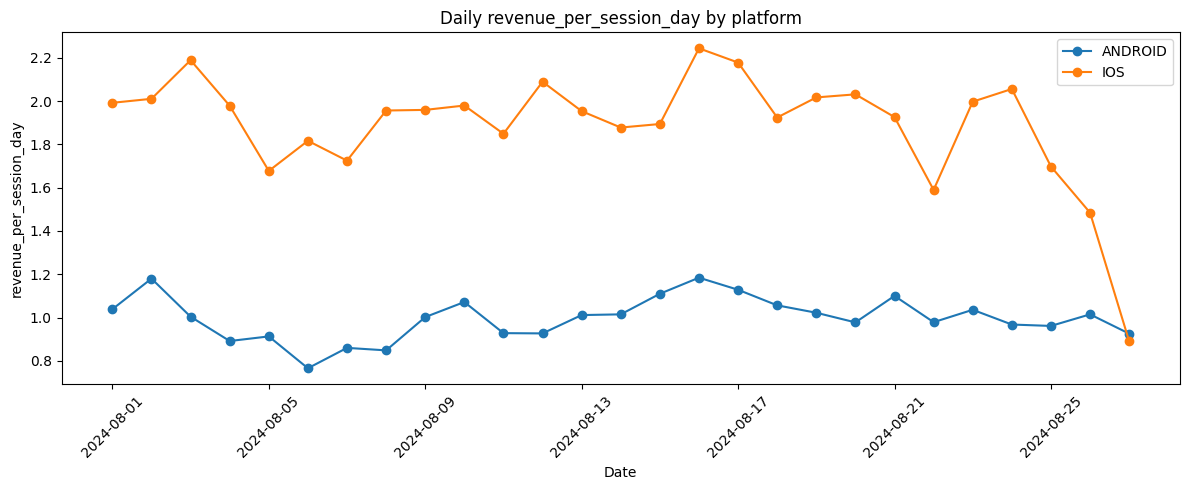

In [98]:
import matplotlib.pyplot as plt

for metric in ["session_days", "conversion_rate", "revenue", "revenue_per_session_day"]:
    plt.figure(figsize=(12, 5))

    for platform in daily_platform["platform"].unique():
        temp = daily_platform[daily_platform["platform"] == platform]
        plt.plot(temp["session_date"], temp[metric], marker="o", label=platform)

    plt.title(f"Daily {metric} by platform")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [106]:
ios_geo_period = con.execute("""
WITH geo_period AS (
    SELECT
        CASE
            WHEN session_date < '2024-08-22' THEN 'before_2024_08_22'
            ELSE 'from_2024_08_22'
        END AS period,
        geo_country,
        COUNT(*) AS session_days,
        SUM(has_purchase) AS buyers,
        SUM(revenue) AS revenue,
        SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
        SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day
    FROM session_day
    WHERE platform = 'IOS'
    GROUP BY period, geo_country
)

SELECT *
FROM geo_period
ORDER BY period, session_days DESC
""").df()

ios_geo_period.head(30)

,period,geo_country,session_days,buyers,revenue,conversion_rate,revenue_per_session_day
0,before_2024_08_22,United States,30498,"3,760.0000","55,056.0800",0.1233,1.8052
1,before_2024_08_22,United Kingdom,25317,"2,464.0000","37,023.3900",0.0973,1.4624
2,before_2024_08_22,Canada,16384,"3,406.0000","53,938.9100",0.2079,3.2922
3,before_2024_08_22,Lithuania,2927,458.0000,"5,869.6300",0.1565,2.0053
4,before_2024_08_22,Morocco,2606,197.0000,"2,579.4500",0.0756,0.9898
5,before_2024_08_22,Poland,1875,238.0000,"3,046.6900",0.1269,1.6249
6,before_2024_08_22,South Africa,1870,237.0000,"3,143.9700",0.1267,1.6813
7,before_2024_08_22,Sweden,1343,165.0000,"2,304.4400",0.1229,1.7159
8,before_2024_08_22,Norway,1208,183.0000,"3,443.1800",0.1515,2.8503
9,before_2024_08_22,Egypt,1188,90.0000,"1,268.3900",0.0758,1.0677


In [107]:
ios_geo_daily_after_22 = con.execute("""
SELECT
    session_date,
    geo_country,
    COUNT(*) AS session_days,
    SUM(has_purchase) AS buyers,
    SUM(revenue) AS revenue,
    SUM(has_purchase) * 1.0 / COUNT(*) AS conversion_rate,
    SUM(revenue) * 1.0 / COUNT(*) AS revenue_per_session_day
FROM session_day
WHERE platform = 'IOS'
  AND session_date >= '2024-08-22'
GROUP BY session_date, geo_country
ORDER BY session_date, session_days DESC
""").df()

ios_geo_daily_after_22.head(50)

,session_date,geo_country,session_days,buyers,revenue,conversion_rate,revenue_per_session_day
0,2024-08-22,United States,1597,189.0000,"2,715.8700",0.1183,1.7006
1,2024-08-22,United Kingdom,1286,89.0000,"1,255.3400",0.0692,0.9762
2,2024-08-22,Canada,916,141.0000,"2,427.9300",0.1539,2.6506
3,2024-08-22,Poland,190,12.0000,136.5300,0.0632,0.7186
4,2024-08-22,Morocco,174,6.0000,44.9400,0.0345,0.2583
5,2024-08-22,Lithuania,150,21.0000,305.3400,0.1400,2.0356
6,2024-08-22,Sweden,67,4.0000,61.4600,0.0597,0.9173
7,2024-08-22,South Africa,67,8.0000,89.4200,0.1194,1.3346
8,2024-08-22,Ireland,64,5.0000,56.4500,0.0781,0.8820
9,2024-08-22,Norway,46,7.0000,190.2800,0.1522,4.1365


### 3. Event table understanding

- click_to_order_1 = earlier order intent, destination known
- click_to_order_2 = deeper order intent, destination + quota known


In [99]:
query = """
SELECT
    event_name,
    COUNT(*) AS event_rows,
    COUNT(DISTINCT unique_session_id) AS unique_session_ids,
    COUNT(plan_destination) AS rows_with_destination,
    COUNT(plan_quota) AS rows_with_quota
FROM events
GROUP BY event_name
ORDER BY event_rows DESC
"""

event_summary = con.execute(query).df()
event_summary.head(15)

,event_name,event_rows,unique_session_ids,rows_with_destination,rows_with_quota
0,click_to_order_1,170437,115088,170436,0
1,click_to_order_2,82013,73420,82013,82013


### 4. Funnel analysis

Important: since events has no session_date, we do not join event flags directly to session_day for daily funnel.  
It would spread the same event across every active day of that unique_session_id.


Creating a period-level purchase table.


In [100]:
visitor_period = con.execute("""
SELECT
    unique_session_id,
    platform,
    geo_country,
    esim_compatible,

    COUNT(DISTINCT session_date) AS active_days,
    COUNT(transaction_id) AS transaction_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions,

    CASE
        WHEN COUNT(transaction_id) > 0 THEN 1
        ELSE 0
    END AS has_purchase,

    SUM(COALESCE(total_billings_in_usd, 0)) AS revenue
FROM sessions
GROUP BY
    unique_session_id,
    platform,
    geo_country,
    esim_compatible
""").df()

con.register("visitor_period", visitor_period)
visitor_period.head()

,unique_session_id,platform,geo_country,esim_compatible,active_days,transaction_rows,unique_transactions,has_purchase,revenue
0,1724331815-4ea3e13b83f8148f478c134f5a17e9b1,ANDROID,Canada,true,1,1,1,1,43.9900
1,1724328128-8360f2e5fa210b9a91a67b11b607f8ee,ANDROID,United States,true,1,0,0,0,0.0000
2,1724300849-58eb4f7d5dd7e0c1d9b707d14d7cd873,ANDROID,United States,true,1,0,0,0,0.0000
3,1724331089-d67a382feaaa3b7fae593dbaf5106ef1,ANDROID,Canada,true,1,0,0,0,0.0000
4,1724354128-b85948e192e1833d2e953947556c1a15,ANDROID,United Kingdom,true,1,0,0,0,0.0000


Creating event flags


In [101]:
event_flags = con.execute("""
SELECT
    unique_session_id,

    MAX(CASE WHEN event_name = 'click_to_order_1' THEN 1 ELSE 0 END) AS has_click_to_order_1,
    MAX(CASE WHEN event_name = 'click_to_order_2' THEN 1 ELSE 0 END) AS has_click_to_order_2,

    COUNT(*) AS total_events
FROM events
GROUP BY unique_session_id
""").df()

con.register("event_flags", event_flags)
event_flags.head()

,unique_session_id,has_click_to_order_1,has_click_to_order_2,total_events
0,1724709787-85d9250152d7174971df6119269db913,1,1,9
1,1723657881-84760254d6015117b400629f7f5880f5,1,1,4
2,1724691627-18EF10E42F074B42ACE37BFB2A31DA64,1,1,2
3,1724322038-f870ae6fa5e675a15f7a8a44d4d7af69,1,1,2
4,1724181418-EB196FC639124F2193D406B6733B8BAE,1,1,5


### 5. Funnel with Android compatibility


In [102]:
funnel_android_compat = con.execute("""
SELECT
    v.platform,
    v.esim_compatible,

    COUNT(*) AS visitors,
    SUM(COALESCE(e.has_click_to_order_1, 0)) AS click_to_order_1,
    SUM(COALESCE(e.has_click_to_order_2, 0)) AS click_to_order_2,
    SUM(v.has_purchase) AS buyers,

    SUM(COALESCE(e.has_click_to_order_1, 0)) * 1.0 / COUNT(*) AS visitor_to_click_1_rate,
    SUM(COALESCE(e.has_click_to_order_2, 0)) * 1.0 / NULLIF(SUM(COALESCE(e.has_click_to_order_1, 0)), 0) AS click_1_to_click_2_rate,
    SUM(v.has_purchase) * 1.0 / NULLIF(SUM(COALESCE(e.has_click_to_order_2, 0)), 0) AS click_2_to_purchase_rate,
    SUM(v.has_purchase) * 1.0 / COUNT(*) AS total_conversion_rate
FROM visitor_period v
LEFT JOIN event_flags e
    ON v.unique_session_id = e.unique_session_id
GROUP BY
    v.platform,
    v.esim_compatible
ORDER BY
    v.platform,
    v.esim_compatible
""").df()

funnel_android_compat

,platform,esim_compatible,visitors,click_to_order_1,click_to_order_2,buyers,visitor_to_click_1_rate,click_1_to_click_2_rate,click_2_to_purchase_rate,total_conversion_rate
0,ANDROID,false,27073,"7,889.0000","4,735.0000",110.0000,0.2914,0.6002,0.0232,0.0041
1,ANDROID,true,85603,"44,666.0000","25,273.0000","8,258.0000",0.5218,0.5658,0.3268,0.0965
2,IOS,not_applicable,128872,"62,532.0000","43,411.0000","16,088.0000",0.4852,0.6942,0.3706,0.1248


### Conclusions

1. iOS wins, but not mainly because buyers spend more.
   - iOS performs better than Android, mainly due to higher conversion rate.  
     Revenue per buyer is quite similar between iOS and Android-compatible users, so the main gap is not buyer spending, but conversion.
2. Android compatibility is a major cause.
   - Android performance should not be evaluated as one single group.  
     Non-compatible Android devices have almost no conversion, which materially lowers Android's overall performance.  
     After separating compatible Android users, the platform gap becomes smaller, although iOS still remains stronger.
3. Funnel insight.
   - Android-compatible users are actually more likely than iOS users to reach the first order click,  
     but they drop more heavily between click_to_order_1 and click_to_order_2, and again before purchase.
     This suggests Android’s issue may be in:
     - plan selection
     - compatibility communication
     - checkout UX, payment
     - technical friction — not lack of initial intent.
4. Incompatible Android users still reach order steps.
   - Although Android users are informed about compatibility, a meaningful share of non-compatible users still reach order-related events.  
     This may indicate that the compatibility warning is not sufficiently early, visible, or well understood.
5. Main anomaly: last-day iOS spike/crash.
   - The main iOS anomaly starts around 2024-08-22.  
     The last day (2024-08-27) is the strongest outlier because traffic spikes while conversion and revenue per session fall sharply.  
     A likely explanation is a change in traffic mix: more low-converting traffic from specific geographies, especially Morocco on the final day.  
     However, the broader decline from 2024-08-22 should also be checked against:
     - campaign changes
     - app releases
     - tracking issues
     - pricing changes
     - payment/checkout problems.
